# Fase 2: Formulación y validación de hipótesis por medio de pruebas estadísticas

In [6]:
# Librerías
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# Carga de datos
df = pd.read_csv('../data/raw_hr_analytics.csv')
print(f"Dataset cargado: {df.shape[0]} registros, {df.shape[1]} variables")

Dataset cargado: 14999 registros, 10 variables


In [48]:
# Distribución de rotación
print("Distribución de rotación:")
print(df['left'].value_counts())
print(f"\nTasa de rotación: {df['left'].mean()*100:.2f}%")

Distribución de rotación:
left
0    11428
1     3571
Name: count, dtype: int64

Tasa de rotación: 23.81%


## HIPÓTESIS 1: Horas trabajadas vs Satisfacción (Correlación de Pearson)
- H0: No existe relación entre average_montly_hours y satisfaction_level
- H1: A más horas trabajadas, menor es la satisfacción

In [67]:
# H1 - Prueba estadística
corr, p_value = stats.pearsonr(df['average_montly_hours'],
                                df['satisfaction_level'])

print("----- Hipótesis 1: Horas vs Satisfacción ----- ")
print(f"- Coeficiente de correlación (r): {corr:.4f}")
print(f"- Valor p: {p_value:.4f}")
print(f"- Nivel de significancia (α): 0.05")

if p_value < 0.05:
    print("Decisión: Rechazamos H0 -> existe correlación significativa")
else:
    print("Decisión: No rechazamos H0 ->no hay correlación significativa")

----- Hipótesis 1: Horas vs Satisfacción ----- 
- Coeficiente de correlación (r): -0.0200
- Valor p: 0.0141
- Nivel de significancia (α): 0.05
Decisión: Rechazamos H0 -> existe correlación significativa


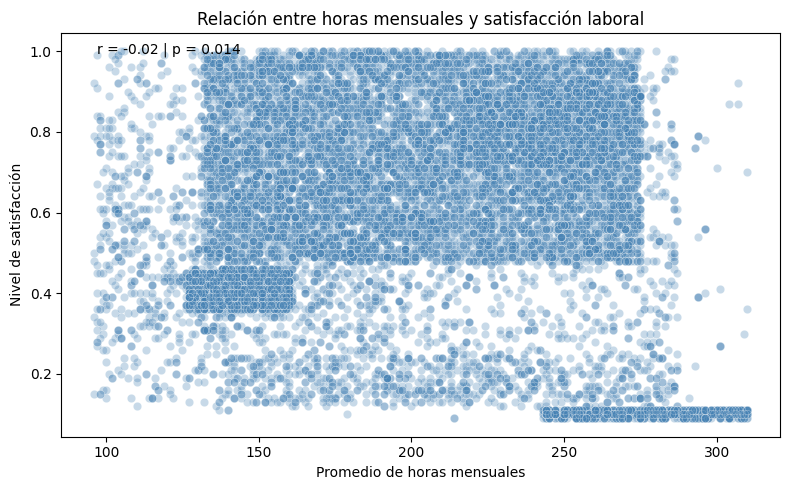

In [54]:
# Visualización H1: Horas vs Satisfacción
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df,
                x='average_montly_hours',
                y='satisfaction_level',
                alpha=0.3,
                color='steelblue')

plt.title('Relación entre horas mensuales y satisfacción laboral')
plt.xlabel('Promedio de horas mensuales')
plt.ylabel('Nivel de satisfacción')
plt.annotate(f'r = -0.02 | p = 0.014',
             xy=(0.05, 0.95),
             xycoords='axes fraction',
             fontsize=10)
plt.tight_layout()
plt.savefig('../dashboard/visualizaciones/h1_horas_vs_satisfaccion.png')
plt.show()

**Interpretación de resultados H1:** Los puntos del gráfico de dispersión están muy dispersos sin una tendencia lineal clara. Se encontró una correlación negativa muy débil (r = -0.02, p = 0.014), lo que indica que aunque la relación es estadísticamente significativa debido al tamaño de la muestra, la carga laboral medida en horas no tienen una relación lineal con la satisfacción del empleado.

In [57]:
# H2 - Discretizar y tabla de contingencia
# Paso 1: calcular mediana y discretizar
mediana = df['satisfaction_level'].median()
print(f"Mediana de satisfaction_level: {mediana}")

df['satisfaction_cat'] = df['satisfaction_level'].apply(
    lambda x: 'bajo' if x < mediana else 'alto'
)

# Paso 2: tabla de contingencia
tabla = pd.crosstab(df['satisfaction_cat'], df['left'])
print("\nTabla de contingencia:")
print(tabla)

# Paso 3: Prueba estadística
chi2, p_value, dof, expected = stats.chi2_contingency(tabla)

print("\n----- Hipótesis 2: Satisfacción vs Rotación -----")
print(f"Chi-cuadrado: {chi2:.4f}")
print(f"Grados de libertad: {dof}")
print(f"Valor p: {p_value:.4f}")
print(f"Nivel de significancia (α): 0.05")

if p_value < 0.05:
    print("Decisión: Rechazamos H0 -> existe asociación significativa")
else:
    print("Decisión: No rechazamos H0 -> no hay asociación significativa")

Mediana de satisfaction_level: 0.64

Tabla de contingencia:
left                 0     1
satisfaction_cat            
alto              6706   959
bajo              4722  2612

----- Hipótesis 2: Satisfacción vs Rotación -----
Chi-cuadrado: 1101.5652
Grados de libertad: 1
Valor p: 0.0000
Nivel de significancia (α): 0.05
Decisión: Rechazamos H0 -> existe asociación significativa


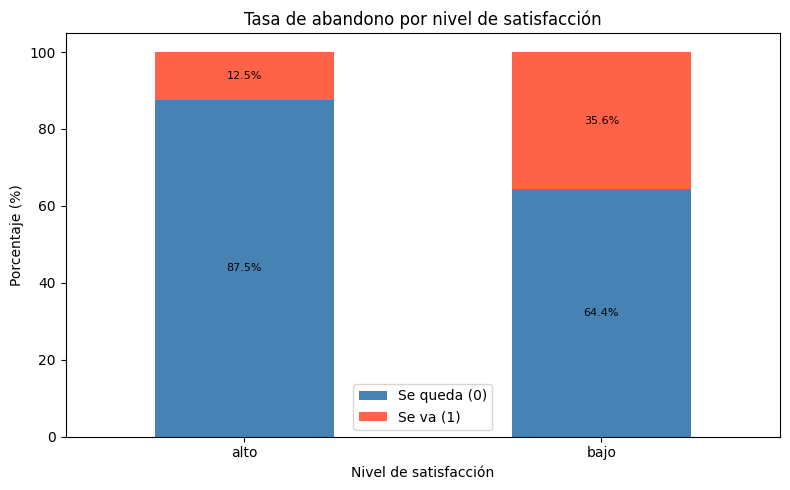

In [68]:
# Visualización H2: Satisfacción vs Rotación
tabla_pct = pd.crosstab(df['satisfaction_cat'],
                         df['left'],
                         normalize='index') * 100

tabla_pct.plot(kind='bar',
               stacked=True,
               figsize=(8, 5),
               color=['steelblue', 'tomato'])

for container in plt.gca().containers:
    plt.gca().bar_label(container,
                        fmt='%.1f%%',
                        label_type='center',
                        fontsize=8)

plt.title('Tasa de abandono por nivel de satisfacción')
plt.xlabel('Nivel de satisfacción')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=0)
plt.legend(['Se queda (0)', 'Se va (1)'])
plt.tight_layout()
plt.savefig('../dashboard/visualizaciones/h2_satisfaccion_vs_rotacion.png')
plt.show()

**Interpretación de resultados H2:** Las barras apiladas muestran que el 12.5% de empleados con satisfacción alta abandona en la empresa, mientras que el 35.6% de empleados con satisfacción baja abandona la empresa. Se encontró una asociación estadísticamente significativa (χ² = 1101.57,gl = 1, p < 0.05), por lo que se rechaza H0 y se concluye que la satisfacción laboral se asocia con la rotación de empleados

## HIPÓTESIS 3: Salario vs Rotación (Chi-cuadrado)
- H0: No existe asociación entre salary y left
- H1: Empleados con salario bajo tienen mayor probabilidad de irse

In [63]:
# Paso 1: tabla de contingencia
tabla_salary = pd.crosstab(df['salary'], df['left'])
print("Tabla de contingencia:")
print(tabla_salary)

# Paso 2: prueba chi-cuadrado
chi2, p_value, dof, expected = stats.chi2_contingency(tabla_salary)

print("\n ---- Hipótesis 3: Salario vs Rotación ----")
print(f"Chi-cuadrado: {chi2:.4f}")
print(f"Grados de libertad: {dof}")
print(f"Valor p: {p_value:.4f}")
print(f"Nivel de significancia (α): 0.05")

if p_value < 0.05:
    print("Decisión: Rechazamos H0 -> existe asociación significativa")
else:
    print("Decisión: No rechazamos H0 -> no hay asociación significativa")



Tabla de contingencia:
left       0     1
salary            
high    1155    82
low     5144  2172
medium  5129  1317

 ---- Hipótesis 3: Salario vs Rotación ----
Chi-cuadrado: 381.2250
Grados de libertad: 2
Valor p: 0.0000
Nivel de significancia (α): 0.05
Decisión: Rechazamos H0 -> existe asociación significativa


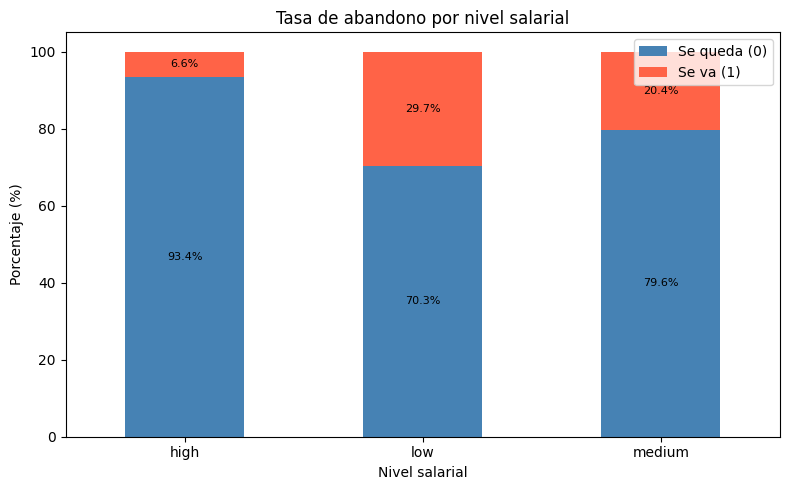

In [69]:
# Visualización H3: Salario vs Rotación
tabla_salary_pct = pd.crosstab(df['salary'],
                                df['left'],
                                normalize='index') * 100

tabla_salary_pct.plot(kind='bar',
                      stacked=True,
                      figsize=(8, 5),
                      color=['steelblue', 'tomato'])

for container in plt.gca().containers:
    plt.gca().bar_label(container,
                        fmt='%.1f%%',
                        label_type='center',
                        fontsize=8)

plt.title('Tasa de abandono por nivel salarial')
plt.xlabel('Nivel salarial')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=0)
plt.legend(['Se queda (0)', 'Se va (1)'])
plt.tight_layout()
plt.savefig('../dashboard/visualizaciones/h3_salario_vs_rotacion.png')
plt.show()

**Interpretación de resultados H3:** El análisis de barras apiladas revela que a menor nivel salarial, mayor tasa de abandono. Los empleados con salario alto presentan una tasa de rotación del 6.6%, los de salario medio del 20.4% y los de salario bajo del 29.7%. Esta diferencia fue confirmada estadísticamente mediante una prueba chi-cuadrado (χ² = 381.22, gl = 2, p < 0.05), por lo que se rechaza H0 y se concluye que existe una asociación significativa entre el nivel salarial y la rotación de empleados.